📦 1. Environment Initialization

In [23]:
import pandas as pd
import streamlit as st
import plotly.express as px

📂 2.1 Data Acquisition 

In [24]:
df = pd.read_csv('Data\DataCoSupplyChainDataset.csv', encoding='latin1')

# Preview the data
print(df.head())

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Ashish\AppData\Local\Temp\ipykernel_12788\3001819920.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  df = pd.read_csv('Data\DataCoSupplyChainDataset.csv', encoding='latin1')


       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1                   1           73  Sporting Goo

📂 2.2 Data Preparation & Cleaning

In [25]:
df.isna().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

📂 2.3 Data Wrangling

In [28]:
# Strip spaces from column headers
df.columns = [col.strip() for col in df.columns]

In [29]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [30]:
#Convert date columns to datetime objects
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipment_date'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [31]:
# . Handling missing values (Filling with 0 or 'Unknown')
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(0)
df['Product Description'] = df['Product Description'].fillna("No Description")

print("Cleaning Complete: Dates converted and columns stripped.")

Cleaning Complete: Dates converted and columns stripped.


In [32]:
df.sample(10)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,order_date,shipment_date
107156,CASH,5,2,-28.340000,125.949997,Late delivery,1,46,Indoor/Outdoor Games,Murfreesboro,...,46,No Description,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,3/13/2017 7:07,Second Class,2017-03-08 07:07:00,2017-03-13 07:07:00
169850,TRANSFER,3,2,122.839996,472.450012,Shipping canceled,0,9,Cardio Equipment,Roswell,...,9,No Description,http://images.acmesports.sports/Nike+Men%27s+F...,Nike Men's Free 5.0+ Running Shoe,99.989998,0,9/25/2015 3:50,Second Class,2015-09-22 03:50:00,2015-09-25 03:50:00
8824,DEBIT,3,4,9.700000,97.000000,Advance shipping,0,24,Women's Apparel,Las Vegas,...,24,No Description,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,9/7/2017 14:55,Standard Class,2017-09-04 14:55:00,2017-09-07 14:55:00
3121,PAYMENT,2,4,-5.020000,44.000000,Advance shipping,0,24,Women's Apparel,Caguas,...,24,No Description,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,2/23/2017 8:42,Standard Class,2017-02-21 08:42:00,2017-02-23 08:42:00
124457,TRANSFER,5,4,53.040001,110.489998,Late delivery,1,18,Men's Footwear,Caguas,...,18,No Description,http://images.acmesports.sports/Nike+Men%27s+C...,Nike Men's CJ Elite 2 TD Football Cleat,129.990005,0,6/27/2016 11:30,Standard Class,2016-06-22 11:30:00,2016-06-27 11:30:00
82055,DEBIT,3,4,190.940002,397.799988,Advance shipping,0,62,Cameras,Eagle Pass,...,62,No Description,http://images.acmesports.sports/Web+Camera,Web Camera,452.040008,0,10/20/2017 5:55,Standard Class,2017-10-17 05:55:00,2017-10-20 05:55:00
56914,DEBIT,2,4,-458.920013,179.970001,Advance shipping,0,17,Cleats,Caguas,...,17,No Description,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,4/11/2016 18:58,Standard Class,2016-04-09 18:58:00,2016-04-11 18:58:00
38113,PAYMENT,6,2,-27.790001,245.960007,Late delivery,1,17,Cleats,Orange Park,...,17,No Description,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,2/24/2015 10:47,Second Class,2015-02-18 10:47:00,2015-02-24 10:47:00
18672,PAYMENT,2,1,10.290000,39.590000,Late delivery,1,29,Shop By Sport,Duluth,...,29,No Description,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,4/9/2015 12:07,First Class,2015-04-07 12:07:00,2015-04-09 12:07:00
107891,PAYMENT,6,4,42.270000,156.570007,Late delivery,1,17,Cleats,Fort Worth,...,17,No Description,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,2/3/2015 1:32,Standard Class,2015-01-28 01:32:00,2015-02-03 01:32:00


🏗️ 3.0 Feature Engineering

In [33]:
# A: Calculate the delay (Actual Days - Scheduled Days)
df['Shipment_Delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# B: Identify Bottleneck Flags
# Any order where Actual > Scheduled is a bottleneck
df['Is_Bottleneck'] = df['Shipment_Delay'] > 0

# C: Order Processing Time (Internal Efficiency)
df['Internal_Processing_Time'] = (df['shipment_date'] - df['order_date']).dt.days

# D: Summary Statistics
total_late = df['Is_Bottleneck'].sum()
late_percentage = (total_late / len(df)) * 100

print(f"Total Orders: {len(df)}")
print(f"Bottleneck Orders: {total_late} ({late_percentage:.2f}%)")

Total Orders: 180519
Bottleneck Orders: 103400 (57.28%)


📊 4.0 Exploratory Data Analysis (EDA)

In [34]:
# Which shipping mode causes the most bottlenecks?
bottleneck_by_mode = df.groupby('Shipping Mode')['Shipment_Delay'].mean().sort_values(ascending=False)
print(bottleneck_by_mode)

# Which categories are consistently late?
bottleneck_by_category = df.groupby('Category Name')['Shipment_Delay'].mean().nlargest(5)
print(bottleneck_by_category)

Shipping Mode
Second Class      1.990828
First Class       1.000000
Same Day          0.478279
Standard Class   -0.004093
Name: Shipment_Delay, dtype: float64
Category Name
Golf Bags & Carts    0.770492
Soccer               0.717391
Pet Supplies         0.709350
Boxing & MMA         0.666667
Strength Training    0.666667
Name: Shipment_Delay, dtype: float64


5. Descriptive Analytics: Target Variable Distribution (Visualizations)

5.1 Systemic Incident Audit (Frequency vs. Percentage)

C:\Users\Ashish\AppData\Local\Temp\ipykernel_12788\4159491599.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['On-Time (0)', 'Bottleneck (1)'])


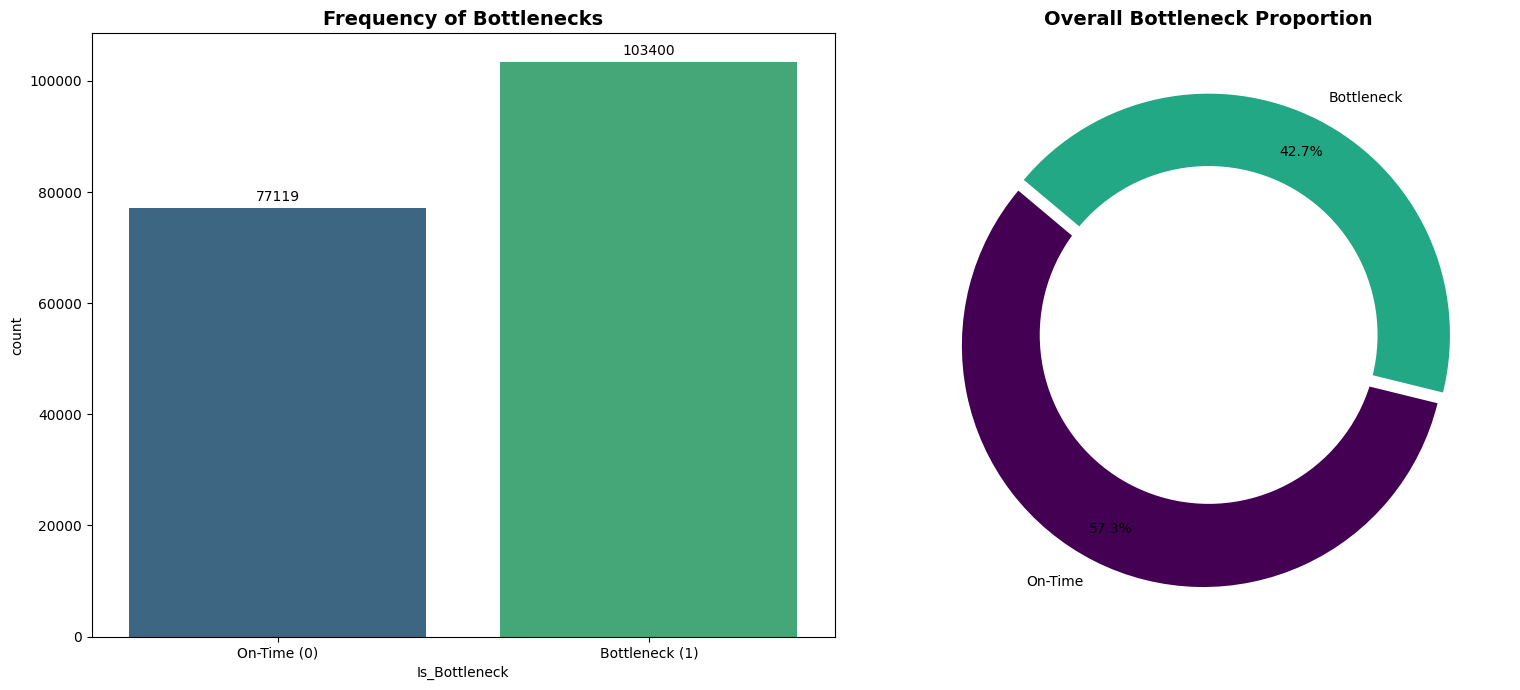

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots show up in your notebook
%matplotlib inline 

# 1. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT PLOT: Bar Chart ---
sns.countplot(
    x='Is_Bottleneck', 
    data=df, 
    hue='Is_Bottleneck', 
    palette='viridis', 
    ax=axes[0], 
    legend=False
)
axes[0].set_title('Frequency of Bottlenecks', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['On-Time (0)', 'Bottleneck (1)'])

# Add labels on top of the bars
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)


# --- RIGHT PLOT: Donut Chart ---
bottleneck_counts = df['Is_Bottleneck'].value_counts()
axes[1].pie(
    bottleneck_counts, 
    labels=['On-Time', 'Bottleneck'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#440154', '#22a884'], # Matching viridis style colors
    pctdistance=0.85, 
    explode=(0.05, 0)
)

# Draw the white circle in the center to make it a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Overall Bottleneck Proportion', fontsize=14, fontweight='bold')

# Final adjustments to prevent overlapping
plt.tight_layout()
plt.show()

5.2 Comparative Analysis: Operational Mode Performance

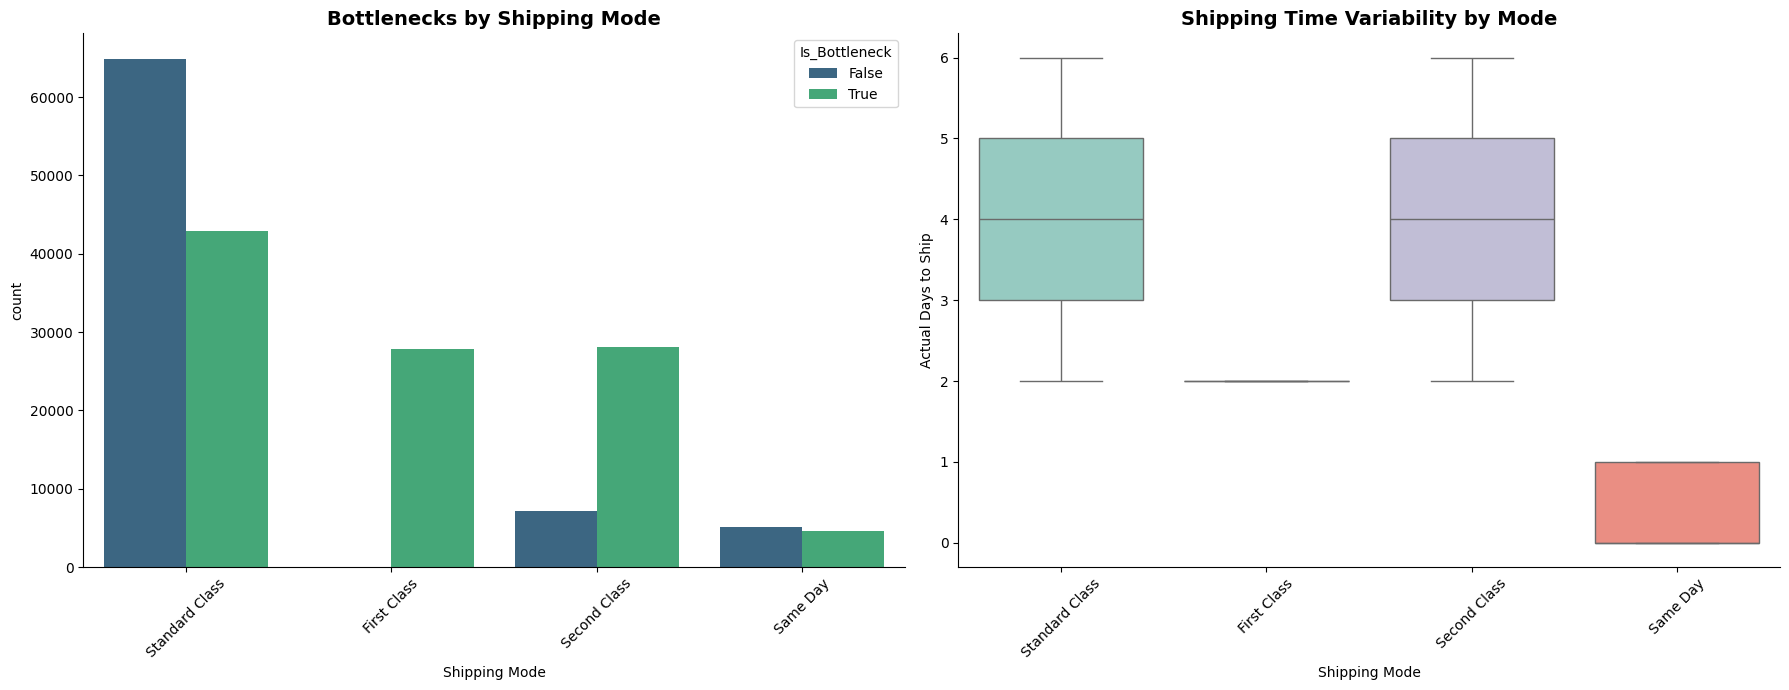

In [36]:
# 1. Create the shared canvas (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- LEFT PLOT: Countplot ---
sns.countplot(
    x='Shipping Mode', 
    hue='Is_Bottleneck', 
    data=df, 
    ax=axes[0], 
    palette='viridis'
)
axes[0].set_title('Bottlenecks by Shipping Mode', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', labelrotation=45) # Correct way to rotate inside subplots

# --- RIGHT PLOT: Boxplot ---
sns.boxplot(
    data=df, 
    x='Shipping Mode', 
    y='Days for shipping (real)', 
    hue='Shipping Mode', 
    ax=axes[1], 
    palette='Set3', 
    legend=False
)
axes[1].set_title('Shipping Time Variability by Mode', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual Days to Ship')
axes[1].tick_params(axis='x', labelrotation=45)

# 2. Professional Polish
sns.despine()
plt.tight_layout() # Prevents labels from overlapping
plt.show()

5.3 Distribution Intelligence: Numerical Variable Profiling

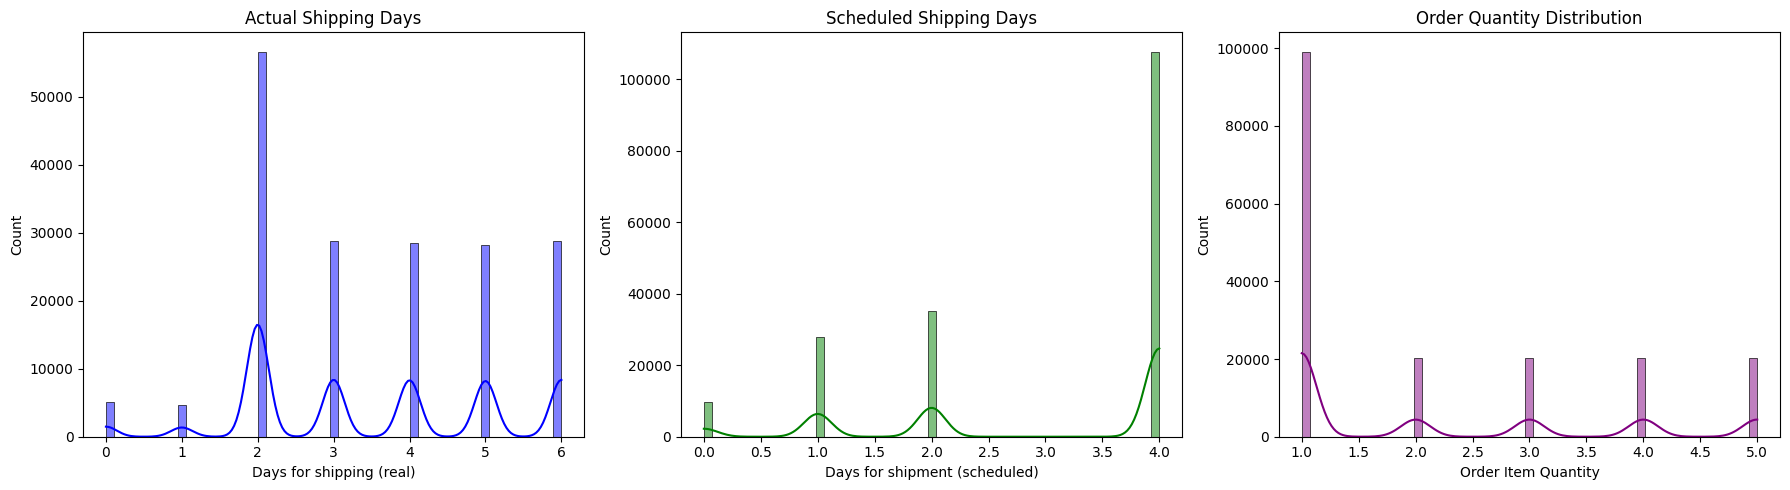

In [37]:
# Numerical Feature Distribution
# Looking at Shipping Days and Order Quantities
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Days for shipping (real)'], kde=True, ax=axes[0], color='blue').set_title('Actual Shipping Days')
sns.histplot(df['Days for shipment (scheduled)'], kde=True, ax=axes[1], color='green').set_title('Scheduled Shipping Days')
sns.histplot(df['Order Item Quantity'], kde=True, ax=axes[2], color='purple').set_title('Order Quantity Distribution')
plt.tight_layout()
plt.show()

5.4 Market-Level Granularity: Latency Density Analysis

C:\Users\Ashish\AppData\Local\Temp\ipykernel_12788\2482834233.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Market', y='Days for shipping (real)', inner="quart", palette='muted')


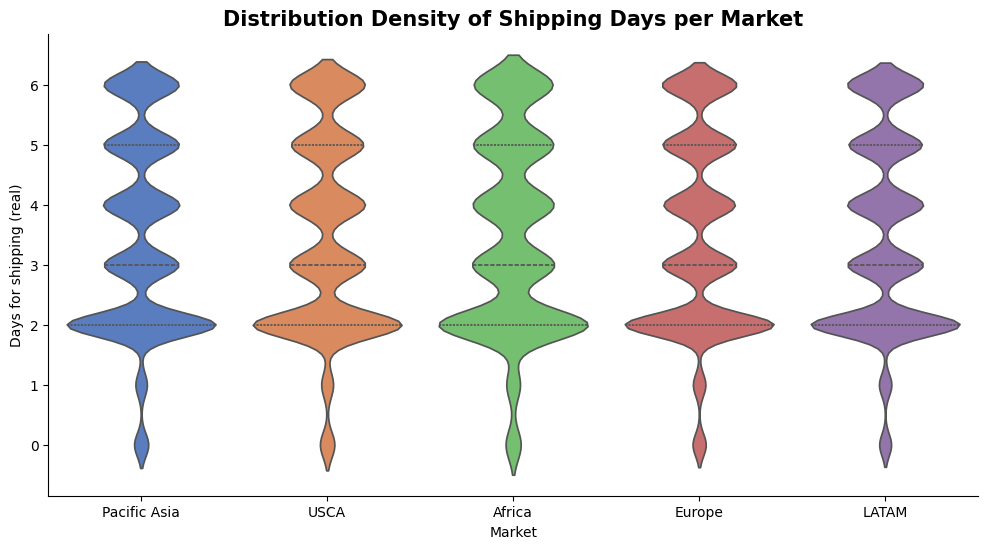

In [38]:
# MULTI-CHART DASHBOARD: Shipping Analysis ---
# Using the "Set2" or "viridis" palette for professional clarity

plt.figure(figsize=(12, 6))
# Distribution of real shipping days by Market
sns.violinplot(data=df, x='Market', y='Days for shipping (real)', inner="quart", palette='muted')

plt.title('Distribution Density of Shipping Days per Market', fontsize=15, fontweight='bold')
sns.despine()
plt.show()

5.5 Correlation Analysis: Value-Based Operational Latency

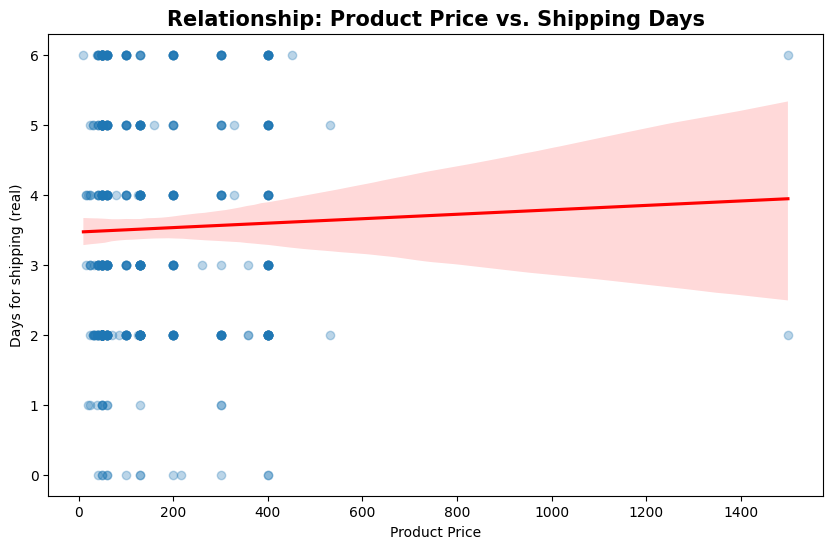

In [39]:
plt.figure(figsize=(10, 6))
# Seeing if more expensive items take longer to ship
sns.regplot(data=df.sample(500), x='Product Price', y='Days for shipping (real)', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Relationship: Product Price vs. Shipping Days', fontsize=15, fontweight='bold')
plt.show()

5.6 Risk Matrix Synthesis: Regional & Operational Intersections

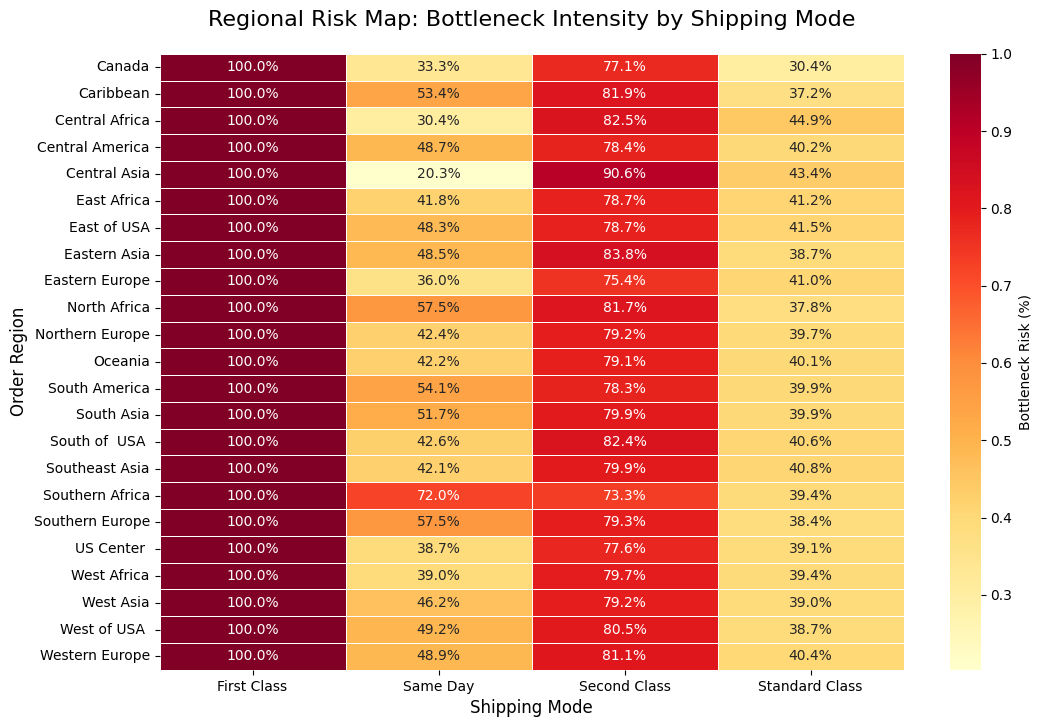

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Data
# We pivot the data to show the average bottleneck rate per Region and Shipping Mode
heatmap_data = df.pivot_table(
    index='Order Region', 
    columns='Shipping Mode', 
    values='Is_Bottleneck', 
    aggfunc='mean'
)

# 2. Plotting
plt.figure(figsize=(12, 8))

# Use a vibrant color map (e.g., 'YlOrRd' for heat or 'rocket' for a modern look)
sns.heatmap(
    heatmap_data, 
    annot=True,          # Show the exact bottleneck percentage in each cell
    fmt=".1%",           # Format numbers as percentages
    cmap="YlOrRd",       # Yellow to Red gradient (higher risk = redder)
    linewidths=.5,       # Add subtle lines between cells for clarity
    cbar_kws={'label': 'Bottleneck Risk (%)'}
)

# 3. Aesthetics
plt.title('Regional Risk Map: Bottleneck Intensity by Shipping Mode', fontsize=16, pad=20)
plt.xlabel('Shipping Mode', fontsize=12)
plt.ylabel('Order Region', fontsize=12)

plt.show()

🚀6.0 Deployment & Integration: Operationalizing Insights

In [41]:
import os
# 1. Clean up any columns with special characters if necessary
# 2. Export to the same folder as your project
df.to_csv('Processed_Supply_Chain_Data.csv', index=False, encoding='utf-8')

print("✅ Data exported successfully as CSV! File Path: {os.path.abspath(output_filename)}")

✅ Data exported successfully as CSV! File Path: {os.path.abspath(output_filename)}
